In [1]:
import numpy as np
import matplotlib.pyplot as plt

import candel
from numpyro.infer import MCMC, NUTS
from jax.random import PRNGKey

from models import *

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [ ]:
catalog_kwargs = {
    "n": 200,
    "rmin": 5,
    "rmax": 80,
    "H0_true": 70.0,
    "sigma_mu": 0.1,
    "sigma_vpec": 300,
    "czmax_sel": 2000,
    "czmax_sel_width": 300,
    "rmax_sel": None,
}


data = candel.mock.gen_simple_catalog(**catalog_kwargs, seed=3)

plt.figure()
plt.hist(data["cz"], bins=20)
plt.show()

In [6]:
# Run inference
kernel = NUTS(model_PV)
mcmc = MCMC(kernel, num_warmup=500, num_samples=1000, num_chains=1)

mcmc.run(
    PRNGKey(42),
    cz=jnp.array(data["cz"]),
    mag=jnp.array(data["mag"]),
    sigma_mu=catalog_kwargs["sigma_mu"],
    sigma_vpec=catalog_kwargs["sigma_vpec"],
    rmin=catalog_kwargs["rmin"],
    rmax=3 * catalog_kwargs["rmax"],
    czmax_sel=catalog_kwargs["czmax_sel"],
    czmax_sel_width=catalog_kwargs["czmax_sel_width"],
    # czmax_sel=None,
    # infer_czmax_sel=True,
    infer_sel=True,
    k=2,
)

# mcmc.print_summary()
samples = mcmc.get_samples()

H0_samples = samples["H0"]
print(f"H0 = {H0_samples.mean():.2f} ± {H0_samples.std():.2f} km/s/Mpc")
print(f"True H0 = {catalog_kwargs['H0_true']}")

if "czmax_sel" in samples:
    czmax_sel_samples = samples["czmax_sel"]
    print(f"czmax_sel = {czmax_sel_samples.mean():.2f} ± {czmax_sel_samples.std():.2f} km/s")
    print(f"True czmax_sel = {catalog_kwargs['czmax_sel']}")

if "czmax_sel_width" in samples:
    czmax_sel_width_samples = samples["czmax_sel_width"]
    print(f"czmax_sel_width = {czmax_sel_width_samples.mean():.2f} ± {czmax_sel_width_samples.std():.2f} km/s")
    print(f"True czmax_sel_width = {catalog_kwargs['czmax_sel_width']}")


sample: 100%|██████████| 1500/1500 [00:01<00:00, 1037.05it/s, 15 steps of size 3.02e-01. acc. prob=0.90]


H0 = 70.76 ± 0.87 km/s/Mpc
True H0 = 70.0
czmax_sel = 1940.49 ± 69.93 km/s
True czmax_sel = 2000
czmax_sel_width = 319.12 ± 45.04 km/s
True czmax_sel_width = 300


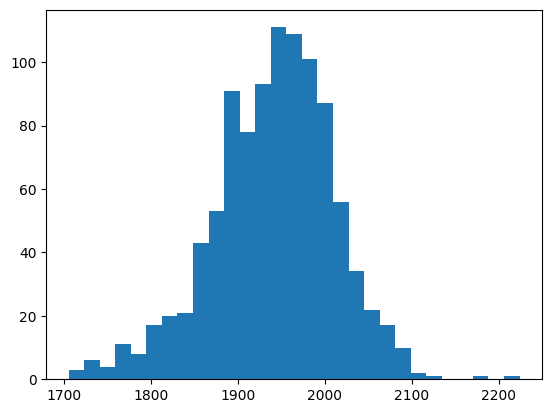

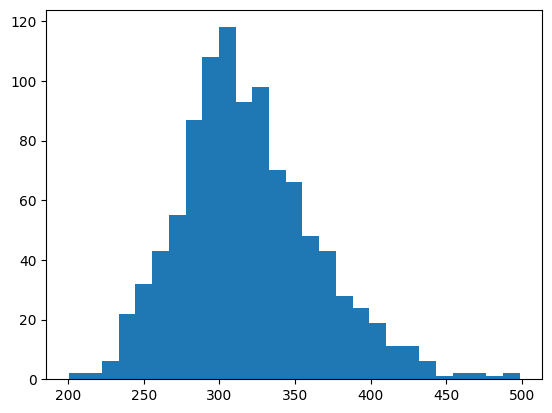

In [7]:
plt.figure()
plt.hist(samples["czmax_sel"], bins="auto")
plt.show()


plt.figure()
plt.hist(samples["czmax_sel_width"], bins="auto")
plt.show()